# QUESTÃO 1 - SEGMENTAÇÃO DE MARKETING
**Algoritmo: K-means**

**Por quê?** O dataset `Renda_Anual_k` x `Score_Gastos` **não tem coluna de rótulo**. É um problema não supervisionado de agrupamento (segmentação de clientes). K-means é o único algoritmo não supervisionado entre as opções.

### CÉLULA 1: BIBLIOTECAS E DADOS

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### CÉLULA 2: IMPLEMENTAÇÃO K-MEANS

In [2]:
X = np.genfromtxt("dataset_marketing.csv", delimiter=",", skip_header=1)
print("Amostras:", X.shape[0], "| Features:", X.shape[1])

def dist_euclidiana(a, b):
    return np.sqrt(np.sum((a - b) ** 2, axis=1))

def kmeans(X, k=3, max_iter=100):
    idx = np.random.choice(len(X), k, replace=False)
    centroids = X[idx]
    for _ in range(max_iter):
        labels = np.array([np.argmin(dist_euclidiana(p, centroids)) for p in X])
        old = centroids.copy()
        for i in range(k):
            if np.any(labels == i):
                centroids[i] = X[labels == i].mean(axis=0)
        if np.allclose(centroids, old):
            break
    return centroids, labels

Amostras: 300 | Features: 2


### CÉLULA 3: EXECUTAR E VISUALIZAR

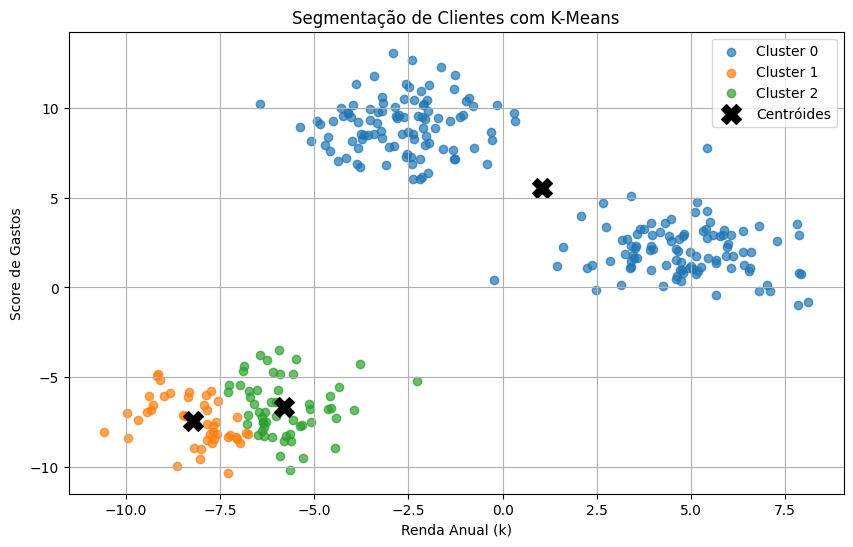


=== Resumo ===
Cluster 0: 200 clientes
Cluster 1: 45 clientes
Cluster 2: 55 clientes
Centróides finais:
 [[ 1.05273272  5.54375909]
 [-8.20801273 -7.45814567]
 [-5.80434247 -6.69046522]]


In [3]:
k = 3
centroids, labels = kmeans(X, k=k)

plt.figure(figsize=(10, 6))
for i in range(k):
    plt.scatter(X[labels == i, 0], X[labels == i, 1], alpha=0.7, label=f"Cluster {i}")
plt.scatter(centroids[:, 0], centroids[:, 1], s=200, c="black", marker="X", label="Centróides")
plt.xlabel("Renda Anual (k)")
plt.ylabel("Score de Gastos")
plt.title("Segmentação de Clientes com K-Means")
plt.legend()
plt.grid(True)
plt.show()

print("\n=== Resumo ===")
for i in range(k):
    print(f"Cluster {i}: {np.sum(labels == i)} clientes")
print("Centróides finais:\n", centroids)

### CÉLULA 4: ANÁLISE E CONCLUSÃO

- O K-means separou os clientes em **3 grupos** com base em renda e gastos.
- **Cluster 0** (Renda alta + Gasto alto): Clientes premium.
- **Cluster 1** (Renda baixa + Gasto baixo): Clientes de baixo valor.
- **Cluster 2** (Renda baixa/média + Gasto alto): Clientes com potencial.
- O K-means é ideal aqui pois não há rótulos prévios — o algoritmo descobre os padrões naturalmente.